# CPU Model Validation
This notebook is intended for people interested in the details of the CPU model used in the VUPC appliance sizing tool. In the code, this is part of the functionality provided in the `RunInfo` class.

Here, I use "private" members of the `RunInfo` class, as well as the same data actually used to fit the model in the sizing tool. This is not the recommended way to use the class; for that, see the description of the public interface in `run_info.py`.
## Setup

In [1]:
import collections
import importlib
import pathlib
import logging
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
from use_core import constants, run_info, task

sys.path.insert(0, "..")
build_models = importlib.import_module("build-models")

sns.set()

run_info.logger.setLevel(logging.CRITICAL)

`RunInfo` expects two objects: one corresponding to an appliance and another to a run/job. These specifications should be "independent" in the sense that any appliance-run pair should be legal.

Here I create classes representing the minimal amount of information that can be provided to the `RunInfo` constructor. I then instantiate them with fake inputs, and use those objects to create `ri` as a `RunInfo` object. The `root_data_dir` and `model_dir` used by `ri` are exactly the same as those used in the real code.

In [2]:
class MockRunConfig:
    def __init__(
        self,
        dedup_ratio: float,
        kb_transferred: int,
        num_streams: int,
        task: str,
        workload_type: str,
        io_duplex: task.TaskDuplexType,
    ) -> None:
        self.dedup_ratio = dedup_ratio
        self.kb_transferred = kb_transferred
        self.num_streams = num_streams
        self.task = task
        self.workload_type = workload_type
        self.io_duplex = io_duplex

class MockApplianceConfig:
    def __init__(
        self,
        appliance: str,
        site_version: str,
        memory: int,
        number_of_total_drives: int,
    ) -> None:
        self.appliance = appliance
        self.site_version = site_version
        self.memory = memory
        self.number_of_total_drives = number_of_total_drives
mock_run_config = MockRunConfig(0.47, 1000000, 10, "backup", "default", task.TaskDuplexType.half)
mock_appliance_config = MockApplianceConfig("5150", constants.SoftwareVersion.VER8_2, 256 * 1024 * 1024, 4)
ri = run_info.RunInfo(mock_run_config,
                      mock_appliance_config,
                      retrain=True,
                      root_data_dir="../data",
                      model_dir="../src/core/use_core/conf/models")

## Getting the data

In [3]:
root_data_dir = pathlib.Path("../data")
data_dir_5150 = root_data_dir / "5150/8.2/default"
cpu_data = build_models.get_cpu_data(data_dir_5150, "backup", "default", "5150")
cpu_data

,dedup_ratio,num_streams,kb_transferred,elapsed_time,kb_throughput,cpu_usage_pct,swapout,cpu_usage_secs
0,0.00,1,30735,595,51,11.391667,0,67.780417
1,0.00,2,61470,1191,51,12.012500,0,143.068875
2,0.00,4,122940,2470,49,12.217550,0,301.773492
3,0.00,8,245880,5039,51,13.982862,77,704.596418
4,0.00,10,307350,6315,52,15.169526,125,957.955594
5,0.50,1,30735,288,106,16.000000,0,46.080000
6,0.50,2,61470,607,101,16.598361,0,100.752049
7,0.50,4,122940,1207,102,15.743772,0,190.027331
8,0.50,8,245880,2468,106,17.182741,7,424.070051
9,0.50,10,307350,3173,106,18.140000,11,575.582200


## Model fitting and validation
The CPU model used here is a "linear model" in the sense that the expectation function is linear in its parameters. The target variable is `cpu_usage_secs`, and the features are `kb_transferred`, the product of `kb_transferred` and `dedup_ratio`, and `swapout` memory required. (So it's linear in the statistics sense, but not the machine learning sense.)

Internally, `_get_or_create_cpu_model()` uses the same data as shown above for training. I do not split the data into separate "training" and "test" sets, for reasons that will be described later on.

Below is a summary of the fitted model. A few points are noteworthy here:
- The $R^2$ value is 0.998. This means that 99.8% of the variation in `cpu_usage_secs` can be accounted for by the three features through this regression.
- The $p$-values on each of the $t$-tests are approximately 0. All of the features are useful here.
- Because of the (strange) nature of the `swapout` data, there is much less certainty about the effect of it on `cpu_usage_secs` than that of the other two features. This is reflected in the standard error of the coefficient and the relatively wide confidence interval.
- Multicollinearity may be an issue, but since our main goal is prediction anyway, it probably doesn't matter much.

In [4]:
fitted_model = ri.cpu_model
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         cpu_usage_secs   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                              2666.
Date:                Wed, 23 Oct 2019   Prob (F-statistic):                    6.47e-23
Time:                        12:17:50   Log-Likelihood:                         -83.782
No. Observations:                  20   AIC:                                      173.6
Df Residuals:                      17   BIC:                                      176.6
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
kb_transferred                 0.0026   8.07e-05     32.503      0.000       0.002       0.003
kb_transferred:dedup_ratio    -0.0019      0.000    -18.470      0.000      -0.002      -0.002
swapout                        1.1173      0.250      4.471      0.000       0.590       1.645
==============================================================================
Omnibus:                       16.841   Durbin-Watson:                   1.474
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.485
Skew:                           1.580   Prob(JB):                     9.68e-05
Kurtosis:                       6.492   Cond. No.                     1.41e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 1.41e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Residual plot
Scary parts about this residual plot:
- The points are not evenly distributed around the 0 line. The residuals are therefore not normal (normal distributions are not right-skewed), which makes the statistics calculated in the summary above suspect.
- If you squint hard enough, you can make out the "megaphone" shape, where larger predicted values correspond to larger residual values. In extreme situations, this might call for a setup where the error variance is a function of the mean (thus eliminating the linear-ness of the model).
- There is a point or two that might be classified as an outlier on this plot.

I don't think this warrants further action for now, for the following reasons:
- The largest residual value is about 50 and corresponds to index 9 of the dataset. This is less than a tenth of the true `cpu_usage_secs` value of 575 for that point.
- Most of the residual values are negative. That means that we are over-predicting the amount of CPU usage required for those runs, because residuals = actual - expected values. Since undersizing is the primary concern with this iteration of the sizer, a bias toward oversizing is not very threatening.

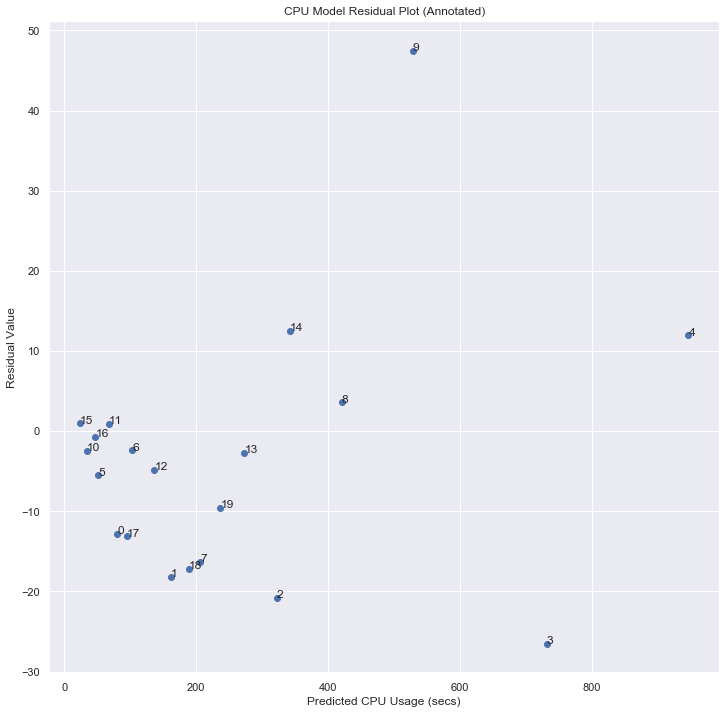

In [5]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(fitted_model.fittedvalues, fitted_model.resid)
ax.set(title="CPU Model Residual Plot (Annotated)", xlabel="Predicted CPU Usage (secs)", ylabel="Residual Value"),
for i, fitted_val in enumerate(fitted_model.fittedvalues):
    resid_val = fitted_model.resid[i]
    ax.annotate(i, (fitted_val, resid_val));

In [6]:
cpu_data.iloc[9]

dedup_ratio            0.5000
num_streams           10.0000
kb_transferred    307350.0000
elapsed_time        3173.0000
kb_throughput        106.0000
cpu_usage_pct         18.1400
swapout               11.0000
cpu_usage_secs       575.5822
Name: 9, dtype: float64

### CPU usage as a function of kilobytes transferred
Based on the description of the model above, for a given dedup ratio value, we expect this relationship to be linear. The plot below, colored by dedup ratio, shows this expected pattern quite clearly. The lack of variation of the points away from the expected pattern makes me worry little about overfitting concerns and be more comfortable with using the full dataset for training.

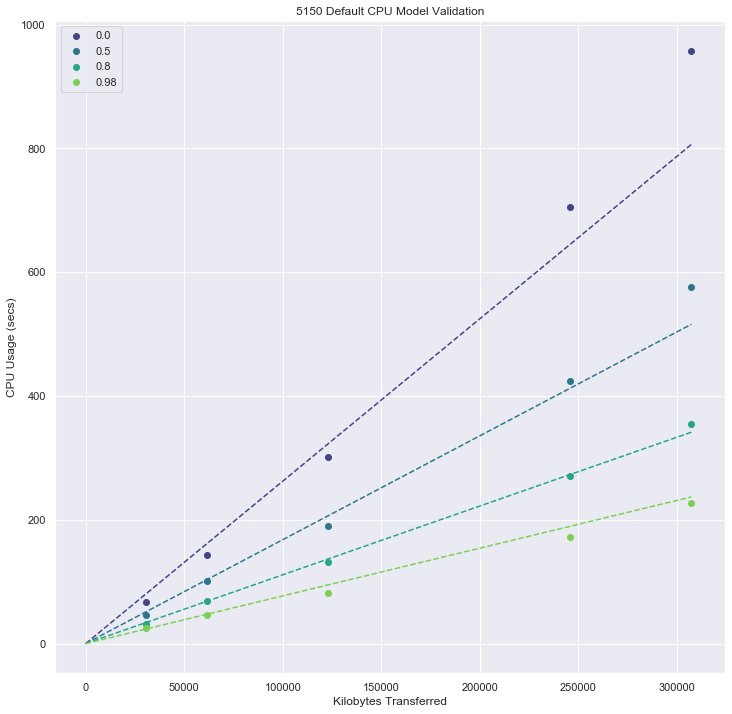

In [7]:
dedup_cat = cpu_data["dedup_ratio"].astype("category")
colors = sns.color_palette("viridis", 4)

max_kb_transferred = cpu_data["kb_transferred"].max()

fig, ax = plt.subplots(figsize=(12, 12))
for i, ddr in enumerate(dedup_cat.cat.categories):
    # Scatter points
    subset_dat = cpu_data.loc[cpu_data["dedup_ratio"] == ddr]
    ax.scatter(subset_dat["kb_transferred"], subset_dat["cpu_usage_secs"], c=[colors[i]], label=str(ddr))

    # Fitted line
    input_range = np.linspace(0, max_kb_transferred, 1000)
    pred_vals = fitted_model.predict(pd.DataFrame({"kb_transferred": input_range, "dedup_ratio": [ddr] * len(input_range), "swapout": [0] * len(input_range)}))
    ax.plot(input_range, pred_vals, c=colors[i], ls="--")
ax.set(title="5150 Default CPU Model Validation", xlabel="Kilobytes Transferred", ylabel="CPU Usage (secs)")
ax.legend(loc="upper left");